# Notebook 2

---

## Overview

While tropycal has methods to analyze rainfall from tropical cyclones, some hurricanes (especially more recent ones) will not have their rainfall data recorded from where tropycal pulls the data from (the Weather Prediction Center). So, we will simply take data from another source (NASA in this case), and make rainfall plots of Hurricane Helene.

---

## Imports

In [ ]:
# If needed, install s3fs package
#!pip install s3fs xarray h5netcdf

In [13]:
# Note: some of these imports are for future work and are not necessary for this current version
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import metpy.calc as mpcalc
from metpy.units import units
import math as m
from CPyS import compute_CPS_parameters
from tropycal import tracks, rain
import s3fs

## 1st Section

In [2]:
rain_ds1 = xr.open_dataset("3B-DAY.MS.MRG.3IMERG.20240927-S000000-E235959.V07B.nc4")
rain_ds1

<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2024-09-27
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB ...
    time_bnds                       (time, nv) datetime64[ns] 16B ...
Attributes:
    BeginDate:       2024-09-27
    BeginTime:       00:00:00.000Z
    EndDate:         2024-09-27
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-09-27T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240927-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2025-01-28T21:47:38.407Z

In [3]:
rain_ds2 = xr.open_dataset("3B-DAY.MS.MRG.3IMERG.20240928-S000000-E235959.V07B.nc4")
rain_ds2

<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 8B 2024-09-28
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB ...
    time_bnds                       (time, nv) datetime64[ns] 16B ...
Attributes:
    BeginDate:       2024-09-28
    BeginTime:       00:00:00.000Z
    EndDate:         2024-09-28
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-09-28T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240928-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2025-01-28T21:49:10.382Z

In [16]:
rain_ds = xr.concat([rain_ds1, rain_ds2], dim='time')
rain_ds.to_netcdf('helene_rainfall_20240927-20240928.nc')

In [17]:
rain_ds

<xarray.Dataset> Size: 233MB
Dimensions:                         (time: 2, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * time                            (time) datetime64[ns] 16B 2024-09-27 2024...
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 52MB 0.0 ... 0.0
    precipitation_cnt               (time, lon, lat) int8 13MB 35 33 ... 27 31
    precipitation_cnt_cond          (time, lon, lat) int8 13MB 0 0 0 0 ... 0 0 0
    MWprecipitation                 (time, lon, lat) float32 52MB nan ... nan
    MWprecipitation_cnt             (time, lon, lat) int8 13MB 0 0 0 0 ... 0 0 0
    MWprecipitation_cnt_cond        (time, lon, lat) int8 13MB 0 0 0 0 ... 0 0 0
    randomError                     (time, lon, lat) float32 52MB 2.016 ... 1...
    randomError_cnt                 (time, lon, lat) int8 13MB 35 33 ... 27 31
    probabilityLiquidPrecipitation  (time, lon, lat) int8 13MB 100 100 ... 100
    time_bnds                       (time, nv) datetime64[ns] 32B 2024-09-27 ...
Attributes:
    BeginDate:       2024-09-27
    BeginTime:       00:00:00.000Z
    EndDate:         2024-09-27
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2024-09-27T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20240927-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2025-01-28T21:47:38.407Z

In [82]:
precip = rain_ds2['precipitation'].squeeze().transpose('lat','lon') * units('mm').to('cm')
lons = rain_ds2['lon']
lats = rain_ds2['lat']
print(precip, "\n", lons, "\n", lats)

<xarray.DataArray 'precipitation' (lat: 1800, lon: 3600)> Size: 26MB
<Quantity([[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]], 'centimeter')>
Coordinates:
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
    time     datetime64[ns] 8B 2024-09-28 
 <xarray.DataArray 'lon' (lon: 3600)> Size: 14kB
array([-179.95, -179.85, -179.75, ...,  179.75,  179.85,  179.95],
      shape=(3600,), dtype=float32)
Coordinates:
  * lon      (lon) float32 14kB -179.9 -179.9 -179.8 ... 179.8 179.9 179.9
Attributes:
    units:      degrees_east
    long_name:  Longitude 
 <xarray.DataArray 'lat' (lat: 1800)> Size: 14kB
array([-89.95, -89.85, -89.75, ...,  89.75,  89.85,  89.95], shape=(1800,))
Coordinates:
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
Attributes:
    units:

In [83]:
precip_max = precip.max()
precip_min = precip.min()
print(f'Max Precipitation (cm): {precip_max}\nMin Precipitation (cm): {precip_min}')

Max Precipitation (cm): <xarray.DataArray 'precipitation' ()> Size: 4B
<Quantity(85.33699035644531, 'centimeter')>
Coordinates:
    time     datetime64[ns] 8B 2024-09-28
Min Precipitation (cm): <xarray.DataArray 'precipitation' ()> Size: 4B
<Quantity(0.0, 'centimeter')>
Coordinates:
    time     datetime64[ns] 8B 2024-09-28


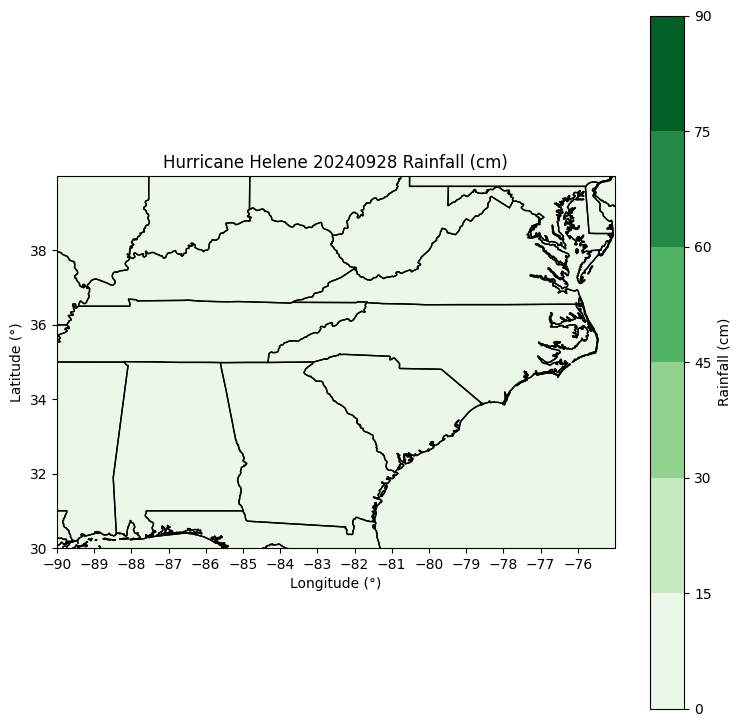

In [84]:
fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-90, -75, 30, 40], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS)
ax.add_feature(cfeature.STATES)

precip_cf = ax.contourf(lons, lats, precip, cmap='Greens', transform=ccrs.PlateCarree())
plt.colorbar(precip_cf, ax=ax, orientation='vertical', label="Rainfall (cm)")

ax.set_xticks(np.arange(-90,-75,1))
ax.set_yticks(np.arange(30,40,2))
ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")
plt.title("Hurricane Helene 20240928 Rainfall (cm)")
plt.show()

---

## Summary

Even though tropycal has several functions for rainfall, sometimes the data it pulls does not have rainfall data for a specific hurricane, in which workarounds need to be done. By taking rainfall data from another source, in this case NASA, we can plot several rainfall maps of Hurricane Helene.

## Resources & References

[NASA Rainfall Data](https://gpm.nasa.gov/data)